# 유형 C 상권 분석 — 중구 평일 직장인 × 주말 관광객 × 고령 상인 다중 타겟 페르소나

**분석 목적**: C유형 상권이 지금 어떤 상태이고, 어떤 문제가 있으며, 상권 유형별로 어떤 전략을 써야 매출을 끌어올릴 수 있는가를 데이터로 제시한다.

> ⚠️ **데이터 한계**: 추론 기반 추정매출 + 길단위인구 + 점포-상권 데이터 사용. 단일 타겟 불가 → 시간대·요일별 타겟 스위칭 구조로 분석.

**분석 흐름**
1. 현황 — 규모·시간대·요일·고객 프로파일 + **스위칭 패턴 히트맵**
2. 상권 세분화 — K-Means 4개 유형 도출
3. 유형별 문제 진단 + 맞춤 전략 + **예상 매출 지표**
4. 지도 시각화 (유형별 색상)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import folium
from folium.plugins import MiniMap
from pyproj import Transformer
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

OKR_COLORS = ['#2166ac', '#d6604d', '#1a9850', '#f4a582']

# 노트북 파일 위치 기준 절대경로 산출 (어느 디렉토리에서 실행해도 안전)
BASE = (Path(__file__).parent / '../data/extracted').resolve() if '__file__' in dir() else \
       (Path().resolve().parent / 'data' / 'extracted')
# Jupyter 환경에서는 cwd가 notebooks/ 이므로 한 단계 위로
if not (BASE / '서울시_상권분석서비스(추정매출+영역)').exists():
    BASE = (Path().resolve() / '../data/extracted').resolve()
print(f'BASE: {BASE}')

BASE: C:\sparta\project\03_final\seouldf\data\extracted


In [8]:
# ── 1. 영역 데이터: 중구 상권 목록 + 좌표 변환
df_area = pd.read_csv(
    BASE / '서울시_상권분석서비스(추정매출+영역)' / '서울시 상권분석서비스(영역-상권).csv',
    encoding='euc-kr'
)
TARGET_GU = ['중구']
df_area_c = df_area[df_area['자치구_코드_명'].isin(TARGET_GU)].copy()
target_codes = set(df_area_c['상권_코드'])

# TM(EPSG:5174) → WGS84(EPSG:4326)
transformer = Transformer.from_crs('EPSG:5174', 'EPSG:4326', always_xy=True)
lons, lats = transformer.transform(
    df_area_c['엑스좌표_값'].values,
    df_area_c['와이좌표_값'].values
)
df_area_c = df_area_c.copy()
df_area_c['lat'] = lats
df_area_c['lon'] = lons

print(f'대상 상권 수: {len(df_area_c)}개')
df_area_c[['상권_코드_명', '자치구_코드_명', 'lat', 'lon']].head(5)

대상 상권 수: 68개


,상권_코드_명,자치구_코드_명,lat,lon
22,경향신문사,중구,37.569635,126.969693
23,회현역 1번,중구,37.560979,126.981604
38,황학코아루아파트,중구,37.569051,127.023574
42,중구회현체육센터(정화예술대남산캠퍼스),중구,37.558880,126.982906
43,남산케이블카,중구,37.559151,126.985611


In [9]:
# ── 2. 추정매출 2025년 4분기(20254) + 중구 필터
df_sales_raw = pd.read_csv(
    BASE / '서울시_상권분석서비스(추정매출+영역)' / '서울시_상권분석서비스(추정매출-상권)_2025년.csv',
    encoding='euc-kr'
)
df_sales_c = df_sales_raw[
    (df_sales_raw['기준_년분기_코드'] == 20254) &
    (df_sales_raw['상권_코드'].isin(target_codes))
].copy()

# ── 3. 길단위 인구 + 중구 필터
df_pop_raw = pd.read_csv(
    BASE / '서울시 상권분석서비스(길단위인구-상권)' / '서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='euc-kr'
)
df_pop_c = df_pop_raw[df_pop_raw['상권_코드'].isin(target_codes)].copy()

# ── 4. 점포 데이터 2024년 4분기(20244) + 중구 필터
# 디렉토리를 순회하여 점포 폴더를 찾음 (한글 경로 직접 접근 오류 우회)
_store_dir = next(d for d in BASE.iterdir() if d.is_dir() and '점포' in d.name)
_store_file = next(f for f in _store_dir.iterdir() if '2024' in f.name and f.suffix == '.csv')
df_store_raw = pd.read_csv(_store_file, encoding='euc-kr')
df_store_c = df_store_raw[
    (df_store_raw['기준_년분기_코드'] == 20244) &
    (df_store_raw['상권_코드'].isin(target_codes))
].copy()

# ── 5. 직장인구 2025년 4분기 + 중구 필터
df_worker_raw = pd.read_csv(
    BASE / '서울시 상권분석서비스(직장인구-상권)' / '서울시 상권분석서비스(직장인구-상권).csv',
    encoding='euc-kr'
)
df_worker_c = df_worker_raw[
    (df_worker_raw['기준_년분기_코드'] == 20254) &
    (df_worker_raw['상권_코드'].isin(target_codes))
].copy()

print(f'추정매출: {len(df_sales_c)}행 / {df_sales_c["상권_코드"].nunique()}개 상권')
print(f'길단위인구: {len(df_pop_c)}행')
print(f'점포(2024Q4): {len(df_store_c)}행 / {df_store_c["상권_코드"].nunique()}개 상권')
print(f'직장인구: {len(df_worker_c)}행 / {df_worker_c["상권_코드"].nunique()}개 상권')
print(f'업종 종류: {df_sales_c["서비스_업종_코드_명"].nunique()}개')
df_sales_c[['상권_코드_명', '서비스_업종_코드_명', '당월_매출_금액', '당월_매출_건수']].head(5)

추정매출: 921행 / 65개 상권
길단위인구: 1904행
점포(2024Q4): 3170행 / 68개 상권
직장인구: 68행 / 68개 상권
업종 종류: 60개


,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수
123,동대문패션타운 관광특구,전자상거래업,4020585,59
124,동대문패션타운 관광특구,인테리어,283917628,2926
125,동대문패션타운 관광특구,철물점,924519063,15448
126,동대문패션타운 관광특구,가구,1093207084,1416
127,동대문패션타운 관광특구,화초,32254075,657


In [10]:
# ── 상권별 핵심 지표 집계 (클러스터링 피처 포함)
g = df_sales_c.groupby('상권_코드').agg(
    총매출=('당월_매출_금액', 'sum'),
    총건수=('당월_매출_건수', 'sum'),
    오전매출=('시간대_06~11_매출_금액', 'sum'),
    점심매출=('시간대_11~14_매출_금액', 'sum'),
    오후매출=('시간대_14~17_매출_금액', 'sum'),
    저녁매출=('시간대_17~21_매출_금액', 'sum'),
    야간매출=('시간대_21~24_매출_금액', 'sum'),
    주중매출=('주중_매출_금액', 'sum'),
    주말매출=('주말_매출_금액', 'sum'),
    주중건수=('주중_매출_건수', 'sum'),
    주말건수=('주말_매출_건수', 'sum'),
    남성매출=('남성_매출_금액', 'sum'),
    여성매출=('여성_매출_금액', 'sum'),
    연령20매출=('연령대_20_매출_금액', 'sum'),
    연령30매출=('연령대_30_매출_금액', 'sum'),
    연령40매출=('연령대_40_매출_금액', 'sum'),
    연령50매출=('연령대_50_매출_금액', 'sum'),
    연령60매출=('연령대_60_이상_매출_금액', 'sum'),
).reset_index()

# 비율 피처 (클러스터링에 사용)
g['점심비중'] = g['점심매출'] / g['총매출']
g['저녁비중'] = g['저녁매출'] / g['총매출']
g['야간비중'] = g['야간매출'] / g['총매출']
g['주말비중'] = g['주말매출'] / g['총매출']
g['여성비중'] = g['여성매출'] / g['총매출']
g['연령60비중'] = g['연령60매출'] / g['총매출']
g['객단가'] = g['총매출'] / g['총건수'].replace(0, np.nan)

# 스위칭 지표: 주말 객단가 / 주중 객단가 (실제 건수 기반 — 관광 vs 직장인 패턴 분리)
g['주중객단가'] = (g['주중매출'] / g['주중건수'].replace(0, np.nan))
g['주말객단가'] = (g['주말매출'] / g['주말건수'].replace(0, np.nan))
g['스위칭비율'] = (g['주말객단가'] / g['주중객단가'].replace(0, np.nan)).clip(0, 5)

# 점포 개업률/폐업률 집계 (상권별 평균)
store_agg = df_store_c.groupby('상권_코드').agg(
    총점포수=('점포_수', 'sum'),
    개업률=('개업_율', 'mean'),
    폐업률=('폐업_률', 'mean'),
    프랜차이즈비율=('프랜차이즈_점포_수', 'sum'),
).reset_index()
store_agg['프랜차이즈비율'] = (
    store_agg['프랜차이즈비율'] / store_agg['총점포수'].replace(0, np.nan)
)

# 직장인구 집계
worker_agg = df_worker_c.groupby('상권_코드').agg(
    직장인구=('총_직장_인구_수', 'mean'),
    직장_연령30=('연령대_30_직장_인구_수', 'mean'),
    직장_연령40=('연령대_40_직장_인구_수', 'mean'),
).reset_index()

# 상권명·좌표 합류
g = g.merge(
    df_area_c[['상권_코드', '상권_코드_명', '자치구_코드_명', 'lat', 'lon']],
    on='상권_코드', how='left'
)
g = g.merge(store_agg, on='상권_코드', how='left')
g = g.merge(worker_agg, on='상권_코드', how='left')

g = g.dropna(subset=['총매출', '점심비중', '저녁비중', '야간비중', '주말비중', '여성비중', '객단가'])
g = g[g['총매출'] > 0].reset_index(drop=True)

g['총매출_억'] = g['총매출'] / 1e8

print(f'분석 상권: {len(g)}개')
print(f'월 평균 매출: {g["총매출_억"].mean():.1f}억원  (중앙값 {g["총매출_억"].median():.1f}억원)')
print(f'객단가 중앙값: {g["객단가"].median():,.0f}원')
print(f'60대 이상 매출 비중 평균: {g["연령60비중"].mean()*100:.1f}%')
print(f'주말 매출 비중 평균: {g["주말비중"].mean()*100:.1f}%')
print(f'스위칭비율 중앙값(주말객단가/주중객단가): {g["스위칭비율"].median():.2f}')

분석 상권: 65개
월 평균 매출: 327.5억원  (중앙값 87.2억원)
객단가 중앙값: 34,095원
60대 이상 매출 비중 평균: 23.5%
주말 매출 비중 평균: 19.6%
스위칭비율 중앙값(주말객단가/주중객단가): 0.96


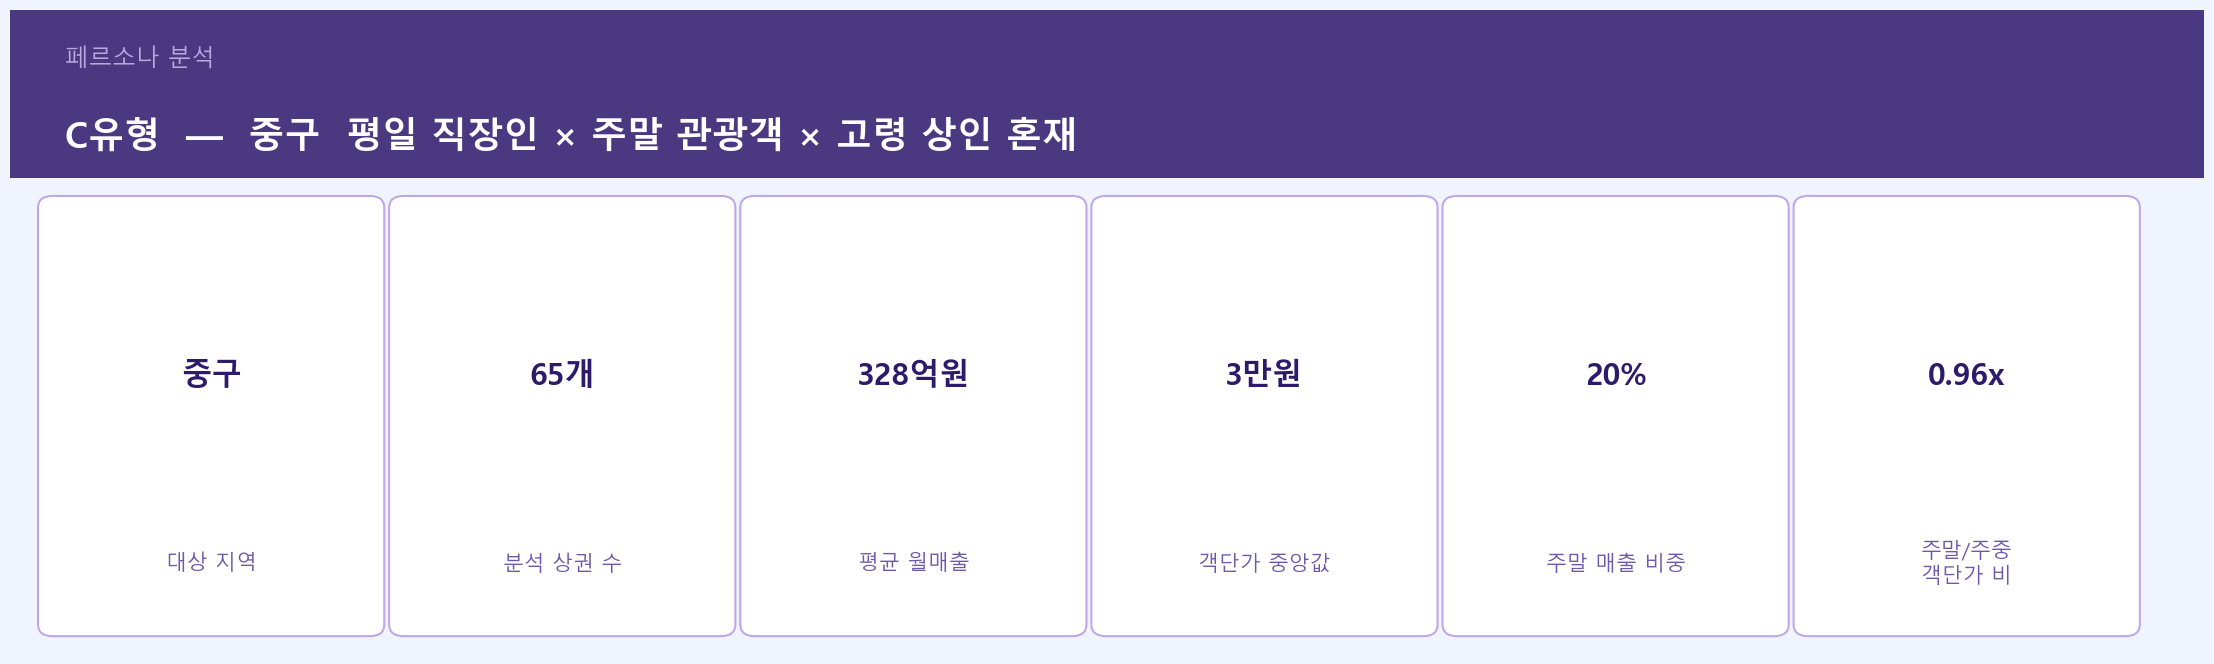

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

avg_sales   = g['총매출_억'].mean()
median_unit = g['객단가'].median()
senior_pct  = g['연령60비중'].mean() * 100
weekend_pct = g['주말비중'].mean() * 100
switch_ratio = g['스위칭비율'].median()

attrs = [
    ('대상 지역',       '중구'),
    ('분석 상권 수',     f'{len(g)}개'),
    ('평균 월매출',      f'{avg_sales:.0f}억원'),
    ('객단가 중앙값',     f'{median_unit/10000:.0f}만원'),
    ('주말 매출 비중',    f'{weekend_pct:.0f}%'),
    ('주말/주중\n객단가 비', f'{switch_ratio:.2f}x'),
]

fig = plt.figure(figsize=(22, 6.5))
ax  = fig.add_subplot(111)
ax.set_xlim(0, 18)
ax.set_ylim(0, 6.5)
ax.axis('off')
fig.patch.set_facecolor('#f0f4ff')
ax.set_facecolor('#f0f4ff')

# 헤더 (복합 타겟 느낌 — 보라/남 계열)
ax.add_patch(FancyBboxPatch((0, 4.8), 18, 1.7, boxstyle='square,pad=0',
                             facecolor='#4a3880', edgecolor='none'))
ax.text(0.45, 6.0, '페르소나 분석', fontsize=17, color='#b9a8e0', va='center', style='italic')
ax.text(0.45, 5.2, 'C유형  —  중구  평일 직장인 × 주말 관광객 × 고령 상인 혼재',
        fontsize=26, color='white', fontweight='bold', va='center')

box_w, gap, start_x = 2.6, 0.28, 0.35
for i, (label, value) in enumerate(attrs):
    x = start_x + i * (box_w + gap)
    ax.add_patch(FancyBboxPatch((x, 0.3), box_w, 4.2,
                                 boxstyle='round,pad=0.12',
                                 facecolor='white', edgecolor='#c0a8e8', linewidth=1.5))
    ax.text(x + box_w / 2, 2.8, value,
            ha='center', va='center', fontsize=22, color='#2d1a6b',
            fontweight='bold', multialignment='center', linespacing=1.3)
    ax.text(x + box_w / 2, 0.9, label,
            ha='center', va='center', fontsize=15, color='#6b5aaa')

plt.tight_layout(pad=0.2)
plt.savefig('../data/output/C유형_페르소나카드.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 1. C유형 현황 — 중구 상권은 지금 어디에 있는가

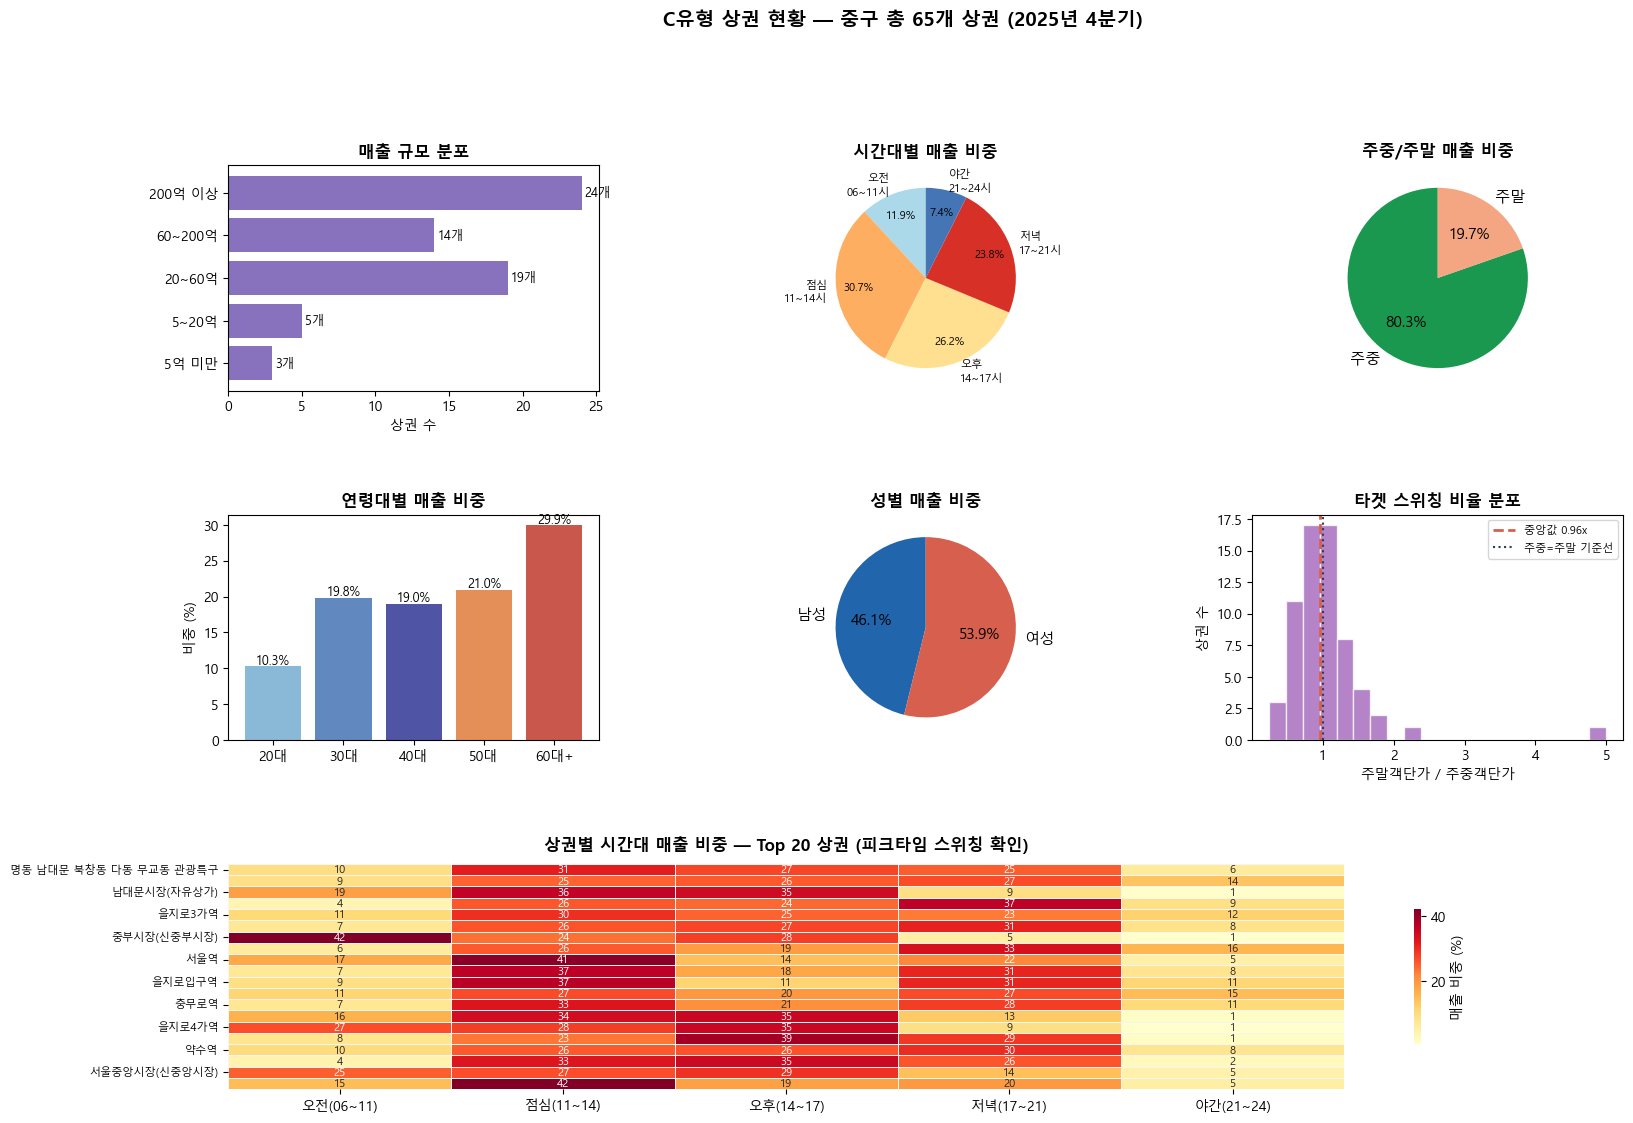

In [12]:
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

# ── (1) 매출 규모 분포
ax1 = fig.add_subplot(gs[0, 0])
bins = [0, 5, 20, 60, 200, g['총매출_억'].max() + 1]
labels_bin = ['5억 미만', '5~20억', '20~60억', '60~200억', '200억 이상']
g['매출구간'] = pd.cut(g['총매출_억'], bins=bins, labels=labels_bin)
매출구간_cnt = g['매출구간'].value_counts().reindex(labels_bin)
bars = ax1.barh(labels_bin, 매출구간_cnt.values, color='#6a4fad', alpha=0.8)
for bar, val in zip(bars, 매출구간_cnt.values):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val}개', va='center', fontsize=9)
ax1.set_xlabel('상권 수')
ax1.set_title('매출 규모 분포', fontweight='bold')

# ── (2) 시간대별 매출 비중
ax2 = fig.add_subplot(gs[0, 1])
time_cols   = ['오전매출', '점심매출', '오후매출', '저녁매출', '야간매출']
time_labels = ['오전\n06~11시', '점심\n11~14시', '오후\n14~17시', '저녁\n17~21시', '야간\n21~24시']
time_vals   = [g[c].sum() for c in time_cols]
time_pct    = [v / sum(time_vals) * 100 for v in time_vals]
colors_t    = ['#abd9e9', '#fdae61', '#fee090', '#d73027', '#4575b4']
wedges, texts, autotexts = ax2.pie(
    time_pct, labels=time_labels, autopct='%1.1f%%',
    colors=colors_t, startangle=90, pctdistance=0.75,
    textprops={'fontsize': 8}
)
for at in autotexts:
    at.set_fontsize(8)
ax2.set_title('시간대별 매출 비중', fontweight='bold')

# ── (3) 주중/주말 매출 비중
ax3 = fig.add_subplot(gs[0, 2])
wd = g['주중매출'].sum()
we = g['주말매출'].sum()
ax3.pie([wd, we], labels=['주중', '주말'],
        autopct='%1.1f%%', colors=['#1a9850', '#f4a582'],
        startangle=90, textprops={'fontsize': 11})
ax3.set_title('주중/주말 매출 비중', fontweight='bold')

# ── (4) 연령대별 매출 비중 (60대 강조)
ax4 = fig.add_subplot(gs[1, 0])
age_cols   = ['연령20매출', '연령30매출', '연령40매출', '연령50매출', '연령60매출']
age_labels = ['20대', '30대', '40대', '50대', '60대+']
age_vals   = [g[c].sum() for c in age_cols]
colors_a   = ['#74add1', '#4575b4', '#313695', '#e07b39', '#c0392b']
ax4.bar(age_labels, [v/sum(age_vals)*100 for v in age_vals], color=colors_a, alpha=0.85)
for i, v in enumerate([v/sum(age_vals)*100 for v in age_vals]):
    ax4.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
ax4.set_ylabel('비중 (%)')
ax4.set_title('연령대별 매출 비중', fontweight='bold')

# ── (5) 성별 매출 비중
ax5 = fig.add_subplot(gs[1, 1])
m_total = g['남성매출'].sum()
f_total = g['여성매출'].sum()
ax5.pie([m_total, f_total], labels=['남성', '여성'],
        autopct='%1.1f%%', colors=['#2166ac', '#d6604d'],
        startangle=90, textprops={'fontsize': 11})
ax5.set_title('성별 매출 비중', fontweight='bold')

# ── (6) 스위칭비율(주말객단가/주중객단가) 분포
ax6 = fig.add_subplot(gs[1, 2])
switch_vals = g['스위칭비율'].dropna()
ax6.hist(switch_vals, bins=20, color='#9b59b6', alpha=0.75, edgecolor='white')
ax6.axvline(switch_vals.median(), color='#d6604d', lw=2, linestyle='--',
            label=f'중앙값 {switch_vals.median():.2f}x')
ax6.axvline(1.0, color='#2c3e50', lw=1.5, linestyle=':',
            label='주중=주말 기준선')
ax6.set_xlabel('주말객단가 / 주중객단가')
ax6.set_ylabel('상권 수')
ax6.set_title('타겟 스위칭 비율 분포', fontweight='bold')
ax6.legend(fontsize=8)

# ── (7) 히트맵: 상권별 시간대 매출 비중 (평균)
ax7 = fig.add_subplot(gs[2, :])
hmap_top = g.nlargest(20, '총매출_억')[['상권_코드_명', '오전매출', '점심매출', '오후매출', '저녁매출', '야간매출']].set_index('상권_코드_명')
hmap_pct = hmap_top.div(hmap_top.sum(axis=1), axis=0) * 100
hmap_pct.columns = ['오전(06~11)', '점심(11~14)', '오후(14~17)', '저녁(17~21)', '야간(21~24)']
sns.heatmap(
    hmap_pct,
    ax=ax7, cmap='YlOrRd', linewidths=0.5, linecolor='#f5f5f5',
    fmt='.0f', annot=True, annot_kws={'size': 8},
    cbar_kws={'label': '매출 비중 (%)', 'shrink': 0.6}
)
ax7.set_xlabel('')
ax7.set_ylabel('')
ax7.set_title('상권별 시간대 매출 비중 — Top 20 상권 (피크타임 스위칭 확인)', fontweight='bold', pad=10)
ax7.tick_params(axis='y', labelsize=8)

fig.suptitle(f'C유형 상권 현황 — 중구 총 {len(g)}개 상권 (2025년 4분기)',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('../data/output/C유형_현황.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. 상권 세분화 — 데이터가 말하는 4가지 유형

시간대·요일별 스위칭 패턴 + 연령·성별·객단가로 K-Means 클러스터링을 수행한다.
C유형의 핵심은 **단일 타겟 불가 구조** — 클러스터별로 지배적 타겟이 다름을 확인한다.

In [13]:
FEAT_COLS = ['점심비중', '저녁비중', '야간비중', '주말비중', '여성비중', '연령60비중']
g['log_객단가'] = np.log(g['객단가'])
g['스위칭비율_안전'] = g['스위칭비율'].fillna(g['스위칭비율'].median())
FEAT_ALL = FEAT_COLS + ['log_객단가', '스위칭비율_안전']

X_raw = g[FEAT_ALL].fillna(0).values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# 최적 k 탐색
sil_scores = {}
for k in range(2, 7):
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil_scores[k] = silhouette_score(X, km_tmp.fit_predict(X))
best_k = max(sil_scores, key=sil_scores.get)
print(f'Silhouette scores: {sil_scores}')
print(f'최적 k = {best_k}')

# k=4 고정 (비즈니스 해석성 우선 — 3대 타겟 + 혼재)
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
g['클러스터'] = km.fit_predict(X)

profile = g.groupby('클러스터')[FEAT_COLS + ['총매출_억', '객단가', '스위칭비율']].mean()
print('\n클러스터별 평균 프로파일:')
print(profile.round(3))

# 유형명 자동 할당
# · 점심비중 MAX    → 평일 직장인 트래픽형
# · 주말비중 MAX    → 주말 관광객 체험형
# · 연령60비중 MAX  → 고령·생활밀착 골목형
# · 나머지           → 혼재 복합형
names_pool = ['① 평일 직장인 트래픽형', '② 주말 관광객 체험형', '③ 고령·생활밀착 골목형', '④ 혼재 복합형']

assigned = {}
# 순서대로 가장 높은 값을 가진 클러스터 할당
max_점심 = profile['점심비중'].idxmax()
max_주말  = profile['주말비중'].idxmax()
max_고령  = profile['연령60비중'].idxmax()
assigned[max_점심] = '① 평일 직장인 트래픽형'
if max_주말 not in assigned:
    assigned[max_주말] = '② 주말 관광객 체험형'
if max_고령 not in assigned:
    assigned[max_고령] = '③ 고령·생활밀착 골목형'
for idx in profile.index:
    if idx not in assigned:
        remaining = [n for n in names_pool if n not in assigned.values()]
        assigned[idx] = remaining[0] if remaining else f'유형{idx}'

profile['유형명'] = pd.Series(assigned)
g['유형명'] = g['클러스터'].map(assigned)

유형_순서 = ['① 평일 직장인 트래픽형', '② 주말 관광객 체험형', '③ 고령·생활밀착 골목형', '④ 혼재 복합형']

print('\n유형별 상권 수:')
print(g['유형명'].value_counts())

Silhouette scores: {2: 0.24296793706819364, 3: 0.2793115807073298, 4: 0.22073869038297161, 5: 0.2309098821783279, 6: 0.2240574829533233}
최적 k = 3

클러스터별 평균 프로파일:
       점심비중   저녁비중   야간비중   주말비중   여성비중  연령60비중    총매출_억         객단가  스위칭비율
클러스터                                                                       
0     0.217  0.322  0.122  0.263  0.418   0.192  498.268   34707.531  1.162
1     0.328  0.136  0.050  0.147  0.539   0.423  255.130   71967.197  0.767
2     0.817  0.053  0.019  0.818  0.046   0.171   18.973  167121.346  5.000
3     0.400  0.208  0.064  0.135  0.281   0.132  214.455   29083.385  0.967

유형별 상권 수:
유형명
② 주말 관광객 체험형     24
④ 혼재 복합형         22
③ 고령·생활밀착 골목형    18
① 평일 직장인 트래픽형     1
Name: count, dtype: int64


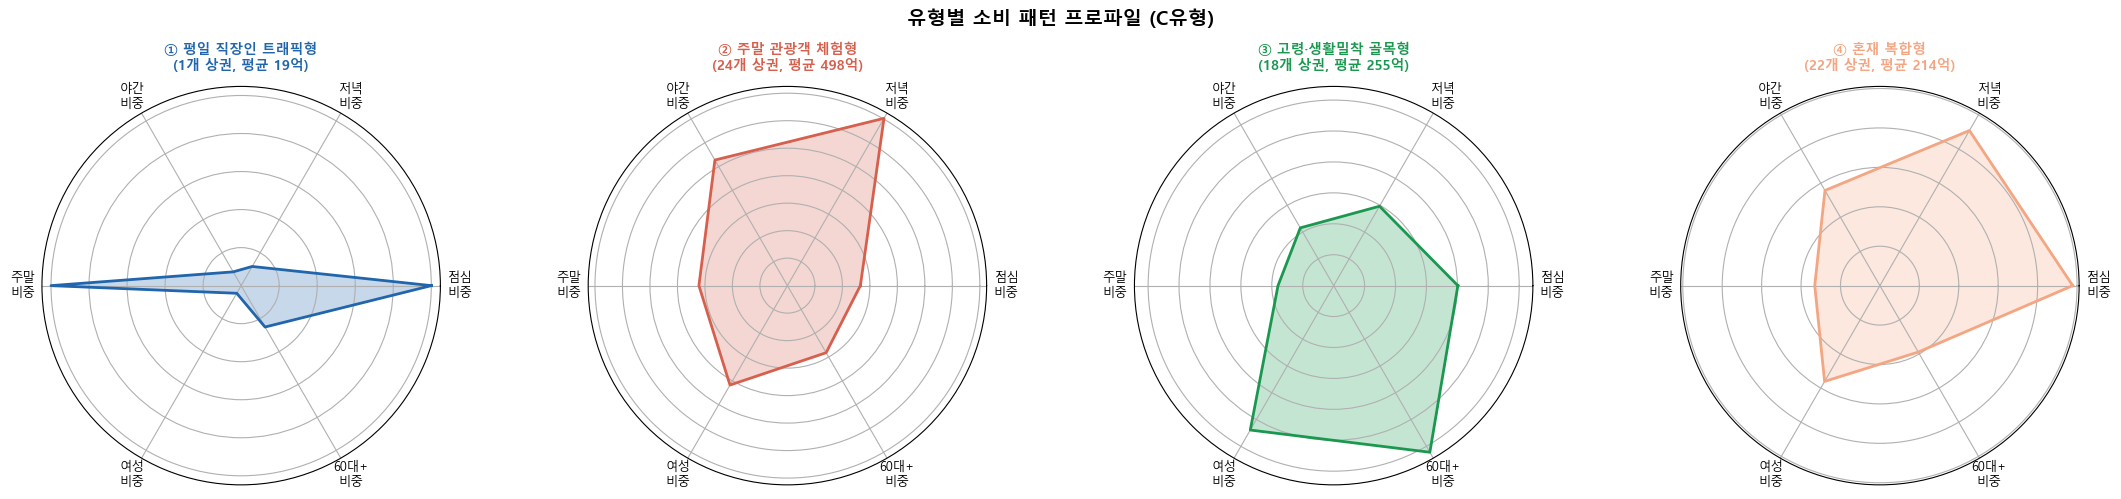

In [14]:
# ── 클러스터 프로파일 레이더 차트
color_map = {유형: OKR_COLORS[i] for i, 유형 in enumerate(유형_순서)}

radar_feats  = ['점심비중', '저녁비중', '야간비중', '주말비중', '여성비중', '연령60비중']
radar_labels = ['점심\n비중', '저녁\n비중', '야간\n비중', '주말\n비중', '여성\n비중', '60대+\n비중']
N = len(radar_feats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

유형_to_cluster = {v: k for k, v in assigned.items()}

fig, axes = plt.subplots(1, 4, figsize=(22, 5), subplot_kw=dict(polar=True))
fig.suptitle('유형별 소비 패턴 프로파일 (C유형)', fontsize=14, fontweight='bold')

for ax, 유형 in zip(axes, 유형_순서):
    cid = 유형_to_cluster.get(유형)
    if cid is None:
        continue
    subset = g[g['클러스터'] == cid]
    vals = [subset[f].mean() for f in radar_feats]
    global_max = [g[f].max() for f in radar_feats]
    vals_norm = [v / m if m > 0 else 0 for v, m in zip(vals, global_max)]
    vals_norm += vals_norm[:1]

    ax.plot(angles, vals_norm, color=color_map[유형], linewidth=2)
    ax.fill(angles, vals_norm, alpha=0.25, color=color_map[유형])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_yticklabels([])
    ax.set_title(
        f'{유형}\n({len(subset)}개 상권, 평균 {subset["총매출_억"].mean():.0f}억)',
        fontsize=10, fontweight='bold', color=color_map[유형], pad=12
    )

plt.tight_layout()
plt.savefig('../data/output/C유형_클러스터_레이더.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. 유형별 문제 진단 + 맞춤 전략 + 예상 매출 지표


  ① 평일 직장인 트래픽형  (1개 상권)
  [문제점] 점심(11~14시) 피크 외 공백이 크고 주말은 사실상 휴면. 좁은 골목 집중으로 피크타임 대기·회전율 저하가 매출 상한을 막음.
    1. AI 웨이팅·모바일 선주문 시스템 도입 (캐치테이블 예약금 제도: 노쇼 1% 미만·회전율 개선 실증)
    2. B2B 모바일 식권·기업 식대 연계 (식권대장: 인근 기업 직원 식대 예산 고정 유입, 을지로·다동·충무로 오피스 벨트 적용)
  현재 19.0억 → 목표 19.0억 (+0.0%), 연간효과 0억

  ② 주말 관광객 체험형  (24개 상권)
  [문제점] 주말 객단가는 높지만 방문 1회성 소비에 그쳐 재방문·연계 소비가 발생하지 않음. 명동·동대문 인근 외국인 비중이 높아 현금·페이 분산으로 데이터 누락 우려.
    1. 체험형 로컬 콘텐츠 투어 운영 (을지OT·황학동 벼룩시장·근현대 역사골목 연계: 재방문율·SNS 바이럴 유도)
    2. 외국인 결제 편의 통합 (Visit Seoul 앱 × 제로페이 외국인 QR: 결제 데이터 포착·객단가 추적 가능성 확보)
  현재 73.1억 → 목표 83.7억 (+14.6%), 연간효과 1534억

  ③ 고령·생활밀착 골목형  (18개 상권)
  [문제점] 60대 이상 상인·거주민 비중이 높아 디지털 소외·현금 의존도가 강함. 개업률보다 폐업률이 높은 상권 하강 사이클 진입 위험.
    1. 시니어 친화 큰 글씨 무인 키오스크 지원 (중기부 2025 스마트상점 기술보급사업: 구매·임차비 보조 → 영세 점포 생존선 확보)
    2. 지역화폐 연계 단골 시니어 리워드 (행안부 지역사랑상품권: 월 3회 이상 방문 캐시백 → 주중 생활밀착 수요 락인)
  현재 125.4억 → 목표 129.3억 (+3.1%), 연간효과 417억

  ④ 혼재 복합형  (22개 상권)
  [문제점] 직장인·관광객·고령층이 공존하지만 어떤 타겟도 지배하지 못해 업종 선택·마케팅 방향이 분산됨. 타겟 부재로 상권 정체성 형성 실

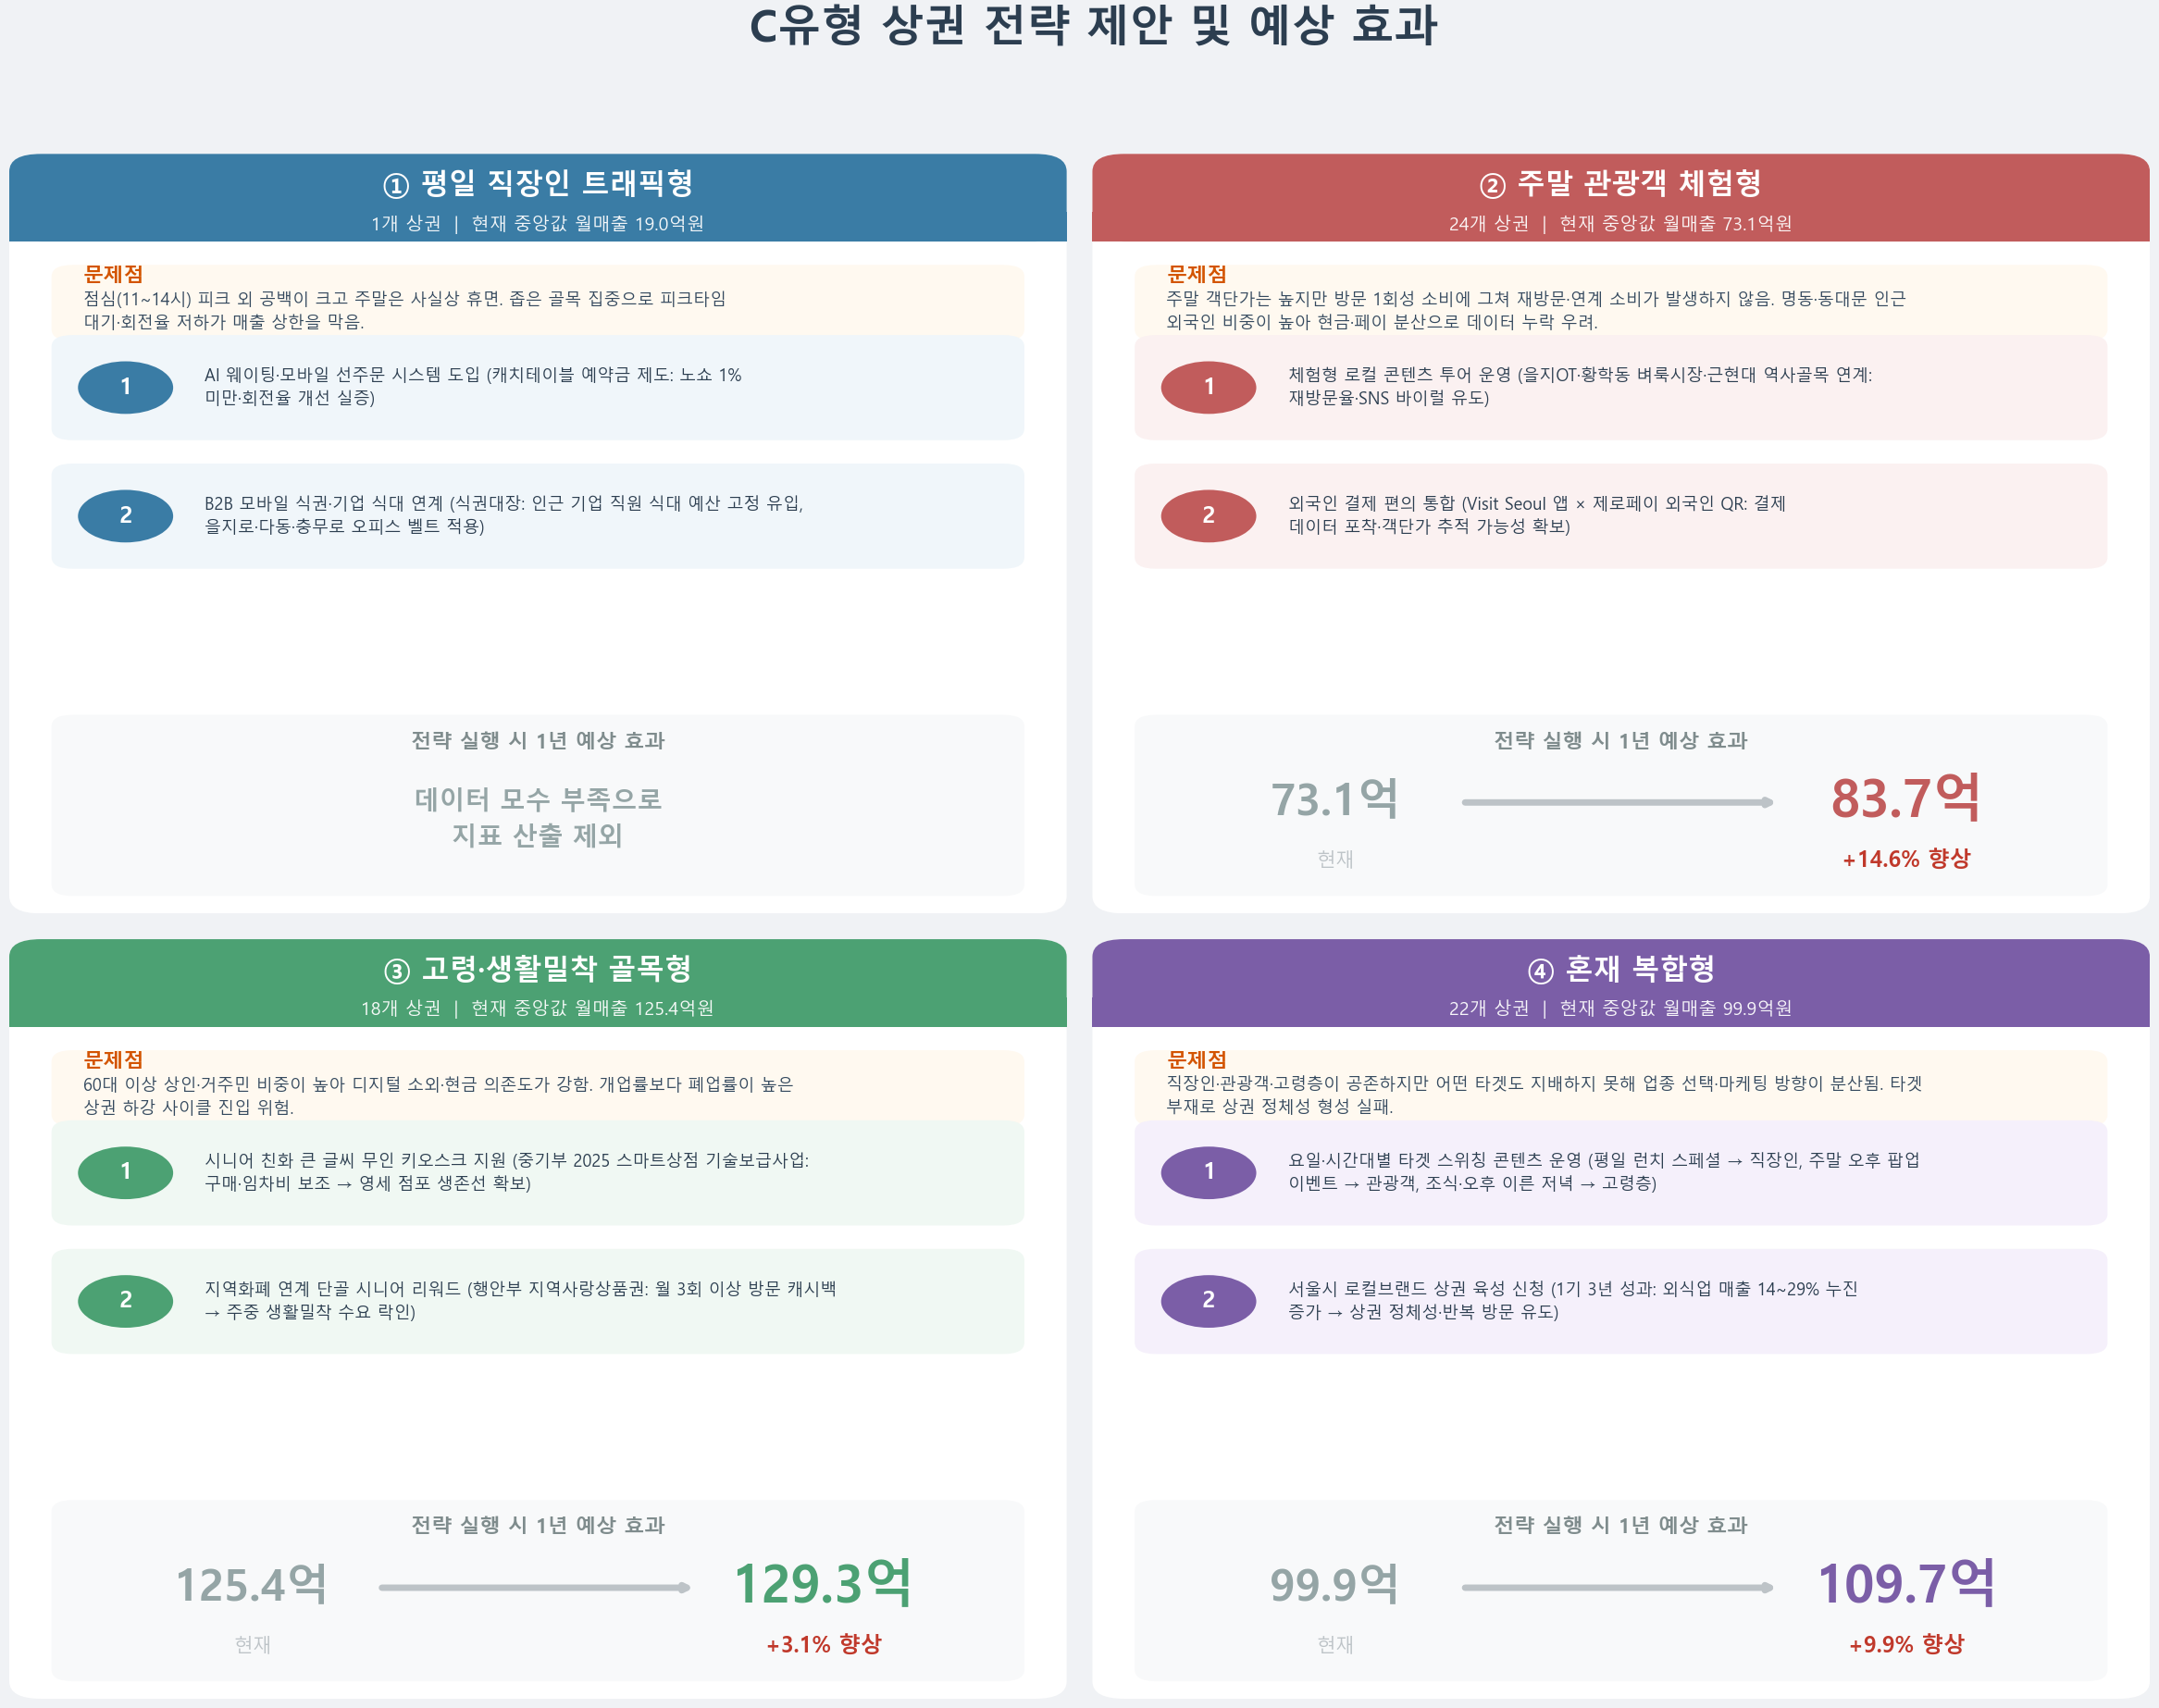

In [15]:
import textwrap, re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

strategy_info = {
    '① 평일 직장인 트래픽형': {
        '문제': '점심(11~14시) 피크 외 공백이 크고 주말은 사실상 휴면. 좁은 골목 집중으로 피크타임 대기·회전율 저하가 매출 상한을 막음.',
        '전략': [
            '1. AI 웨이팅·모바일 선주문 시스템 도입 (캐치테이블 예약금 제도: 노쇼 1% 미만·회전율 개선 실증)',
            '2. B2B 모바일 식권·기업 식대 연계 (식권대장: 인근 기업 직원 식대 예산 고정 유입, 을지로·다동·충무로 오피스 벨트 적용)',
        ],
    },
    '② 주말 관광객 체험형': {
        '문제': '주말 객단가는 높지만 방문 1회성 소비에 그쳐 재방문·연계 소비가 발생하지 않음. 명동·동대문 인근 외국인 비중이 높아 현금·페이 분산으로 데이터 누락 우려.',
        '전략': [
            '1. 체험형 로컬 콘텐츠 투어 운영 (을지OT·황학동 벼룩시장·근현대 역사골목 연계: 재방문율·SNS 바이럴 유도)',
            '2. 외국인 결제 편의 통합 (Visit Seoul 앱 × 제로페이 외국인 QR: 결제 데이터 포착·객단가 추적 가능성 확보)',
        ],
    },
    '③ 고령·생활밀착 골목형': {
        '문제': '60대 이상 상인·거주민 비중이 높아 디지털 소외·현금 의존도가 강함. 개업률보다 폐업률이 높은 상권 하강 사이클 진입 위험.',
        '전략': [
            '1. 시니어 친화 큰 글씨 무인 키오스크 지원 (중기부 2025 스마트상점 기술보급사업: 구매·임차비 보조 → 영세 점포 생존선 확보)',
            '2. 지역화폐 연계 단골 시니어 리워드 (행안부 지역사랑상품권: 월 3회 이상 방문 캐시백 → 주중 생활밀착 수요 락인)',
        ],
    },
    '④ 혼재 복합형': {
        '문제': '직장인·관광객·고령층이 공존하지만 어떤 타겟도 지배하지 못해 업종 선택·마케팅 방향이 분산됨. 타겟 부재로 상권 정체성 형성 실패.',
        '전략': [
            '1. 요일·시간대별 타겟 스위칭 콘텐츠 운영 (평일 런치 스페셜 → 직장인, 주말 오후 팝업 이벤트 → 관광객, 조식·오후 이른 저녁 → 고령층)',
            '2. 서울시 로컬브랜드 상권 육성 신청 (1기 3년 성과: 외식업 매출 14~29% 누진 증가 → 상권 정체성·반복 방문 유도)',
        ],
    },
}

results = {}
for 유형 in 유형_순서:
    cid = 유형_to_cluster.get(유형)
    if cid is None:
        continue
    subset = g[g['클러스터'] == cid]
    현재 = subset['총매출_억'].median()
    상권수 = len(subset)
    현실적_벤치마크 = subset['총매출_억'].quantile(0.60)
    갭 = max(현실적_벤치마크 - 현재, 0)
    최종_목표 = min(현재 + 갭 * 0.15, 현재 * 1.15)
    개선율 = (최종_목표 - 현재) / 현재 * 100 if 현재 > 0 else 0
    연간효과_억 = (최종_목표 - 현재) * 6 * 상권수
    results[유형] = {
        '상권수': 상권수, '현재_억': 현재, '벤치마크_억': 현실적_벤치마크,
        '목표_억': 최종_목표, '개선율_%': 개선율, '연간효과_억': 연간효과_억,
    }
    info = strategy_info.get(유형, {})
    print(f'\n{"="*60}')
    print(f'  {유형}  ({상권수}개 상권)')
    print(f'  [문제점] {info.get("문제", "-")}')
    for s in info.get('전략', []):
        print(f'    {s}')
    print(f'  현재 {현재:.1f}억 → 목표 {최종_목표:.1f}억 (+{개선율:.1f}%), 연간효과 {연간효과_억:.0f}억')

# ── 전략 카드 시각화
CARD_COLORS = {
    '① 평일 직장인 트래픽형':  '#3A7CA5',
    '② 주말 관광객 체험형':   '#C15C5C',
    '③ 고령·생활밀착 골목형':  '#4CA173',
    '④ 혼재 복합형':          '#7B5EA7',
}
LIGHT_COLORS = {
    '① 평일 직장인 트래픽형':  '#F0F6FA',
    '② 주말 관광객 체험형':   '#FBF1F1',
    '③ 고령·생활밀착 골목형':  '#F0F8F3',
    '④ 혼재 복합형':          '#F5F0FB',
}

fig, axes = plt.subplots(2, 2, figsize=(24, 18))
fig.patch.set_facecolor('#F0F2F5')
fig.suptitle('C유형 상권 전략 제안 및 예상 효과', fontsize=34, fontweight='bold', y=1.03, color='#2C3E50')

for ax, 유형 in zip(axes.flat, 유형_순서):
    color  = CARD_COLORS[유형]
    lcolor = LIGHT_COLORS[유형]
    r      = results.get(유형, {})
    info   = strategy_info.get(유형, {})

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 13)
    ax.axis('off')
    ax.add_patch(FancyBboxPatch((0, 0), 10, 13, boxstyle='round,pad=0,rounding_size=0.3',
                                 facecolor='white', edgecolor='none', zorder=0))

    # 헤더
    ax.add_patch(FancyBboxPatch((0, 11.5), 10, 1.5, boxstyle='round,pad=0,rounding_size=0.3',
                                 facecolor=color, edgecolor='none'))
    ax.add_patch(plt.Rectangle((0, 11.5), 10, 0.5, facecolor=color, edgecolor='none'))
    ax.text(5, 12.45, 유형, ha='center', va='center', fontsize=22, color='white', fontweight='bold')
    ax.text(5, 11.8,
            f'{r.get("상권수",0)}개 상권  |  현재 중앙값 월매출 {r.get("현재_억",0):.1f}억원',
            ha='center', va='center', fontsize=14, color='white', alpha=0.95)

    # 문제점
    ax.add_patch(FancyBboxPatch((0.4, 9.8), 9.2, 1.3, boxstyle='round,pad=0,rounding_size=0.2',
                                 facecolor='#FFF9F0', edgecolor='none'))
    ax.text(0.7, 10.8, '문제점', fontsize=16, color='#D35400', fontweight='bold')
    prob_w = textwrap.fill(info.get('문제', ''), width=55)
    ax.text(0.7, 10.3, prob_w, fontsize=13, color='#34495E', va='center', linespacing=1.5)

    # 전략 박스
    strats = info.get('전략', [])
    strat_y_fixed = [8.1, 5.9, 3.7]
    for j, (s, top) in enumerate(zip(strats[:3], strat_y_fixed)):
        ax.add_patch(FancyBboxPatch((0.4, top), 9.2, 1.8, boxstyle='round,pad=0,rounding_size=0.2',
                                     facecolor=lcolor, edgecolor='none'))
        cy = top + 0.9
        ax.add_patch(mpatches.Circle((1.1, cy), 0.45, facecolor=color, edgecolor='none', zorder=3))
        ax.text(1.1, cy, str(j + 1), ha='center', va='center',
                fontsize=18, color='white', fontweight='bold', zorder=4)
        s_clean = re.sub(r'^\d+\.\s*', '', s)
        s_wrap  = textwrap.fill(s_clean, width=48)
        ax.text(1.85, cy, s_wrap, fontsize=13, color='#2C3E50', va='center', linespacing=1.45)

    # 예상 지표
    ax.add_patch(FancyBboxPatch((0.4, 0.3), 9.2, 3.1, boxstyle='round,pad=0,rounding_size=0.2',
                                 facecolor='#F8F9FA', edgecolor='none'))
    ax.text(5, 3.1, '전략 실행 시 1년 예상 효과',
            ha='center', va='top', fontsize=16, color='#7F8C8D', fontweight='bold')

    현재_v  = r.get('현재_억', 0)
    목표_v  = r.get('목표_억', 0)
    개선율_v = r.get('개선율_%', 0)
    if r.get('상권수', 0) <= 1 or 현재_v == 0:
        ax.text(5, 1.6, '데이터 모수 부족으로\n지표 산출 제외',
                ha='center', va='center', fontsize=20, color='#95A5A6',
                fontweight='bold', linespacing=1.5)
    else:
        ax.text(2.3, 1.9, f'{현재_v:.1f}억',
                ha='center', va='center', fontsize=34, color='#95A5A6', fontweight='bold')
        ax.text(2.3, 0.9, '현재', ha='center', va='center', fontsize=15, color='#BDC3C7')
        ax.annotate('', xy=(6.5, 1.9), xytext=(3.5, 1.9),
                    arrowprops=dict(arrowstyle='->', color='#BDC3C7', lw=5.0))
        ax.text(7.7, 1.9, f'{목표_v:.1f}억',
                ha='center', va='center', fontsize=40, color=color, fontweight='bold')
        ax.text(7.7, 0.9, f'+{개선율_v:.1f}% 향상',
                ha='center', va='center', fontsize=17, color='#C0392B', fontweight='bold')

plt.tight_layout(pad=2.0)
plt.savefig('../data/output/C유형_전략카드.png', dpi=300, bbox_inches='tight')
plt.show()

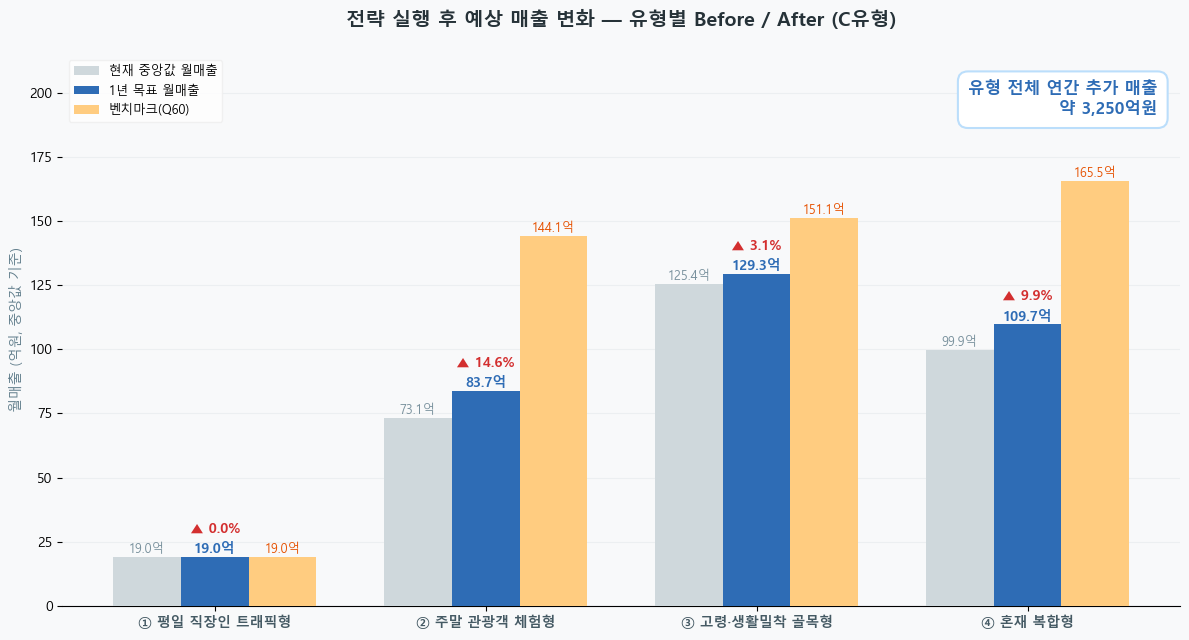

연간 추가 매출 유발 효과: 약 3,250억원


In [16]:
# ── Before / After 매출 비교 차트
유형_labels   = list(results.keys())
현재_vals     = [results[u]['현재_억']    for u in 유형_labels]
목표_vals     = [results[u]['목표_억']    for u in 유형_labels]
벤치마크_vals  = [results[u]['벤치마크_억'] for u in 유형_labels]

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

x     = np.arange(len(유형_labels))
width = 0.25

bars_현재  = ax.bar(x - width, 현재_vals,    width, label='현재 중앙값 월매출', color='#CFD8DC', edgecolor='none', zorder=3)
bars_목표  = ax.bar(x,         목표_vals,    width, label='1년 목표 월매출',    color='#2E6CB5', edgecolor='none', zorder=3)
bars_bench = ax.bar(x + width, 벤치마크_vals, width, label='벤치마크(Q60)',     color='#FFCC80', edgecolor='none', zorder=3)

for bar in bars_현재:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f'{h:.1f}억',
                ha='center', va='bottom', fontsize=9, color='#78909C')

for i, bar in enumerate(bars_목표):
    h = bar.get_height()
    개선율 = results[유형_labels[i]]['개선율_%']
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f'{h:.1f}억',
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2E6CB5')
        ax.text(bar.get_x() + bar.get_width() / 2, h + max(벤치마크_vals) * 0.05,
                f'▲ {개선율:.1f}%', ha='center', va='bottom', fontsize=10,
                fontweight='bold', color='#D32F2F')

for bar in bars_bench:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f'{h:.1f}억',
                ha='center', va='bottom', fontsize=9, color='#E65100')

ax.set_xticks(x)
ax.set_xticklabels(유형_labels, fontsize=10, fontweight='bold', color='#455A64')
ax.set_ylabel('월매출 (억원, 중앙값 기준)', fontsize=10, color='#607D8B')
ax.set_title('전략 실행 후 예상 매출 변화 — 유형별 Before / After (C유형)',
             fontsize=14, fontweight='bold', pad=20, color='#263238')
ax.grid(axis='y', linestyle='-', color='#ECEFF1', zorder=0)
sns.despine(left=True, bottom=False)
ax.legend(fontsize=9, loc='upper left', frameon=True, edgecolor='#EEEEEE', facecolor='white')
ax.set_ylim(0, max(벤치마크_vals) * 1.3 if 벤치마크_vals else 10)

total_연간 = sum(results[u]['연간효과_억'] for u in 유형_labels)
ax.text(0.98, 0.95,
        f'유형 전체 연간 추가 매출\n약 {total_연간:,.0f}억원',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=12, fontweight='bold', color='#2E6CB5',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='#BBDEFB', linewidth=1.5))

plt.tight_layout()
plt.savefig('../data/output/C유형_전략_BeforeAfter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'연간 추가 매출 유발 효과: 약 {total_연간:,.0f}억원')

---
## 4. 지도 시각화 — 유형별 상권 분포

In [17]:
# ── 유형별 색상 Folium 지도
color_map_folium = {
    '① 평일 직장인 트래픽형':  '#2166ac',
    '② 주말 관광객 체험형':   '#d6604d',
    '③ 고령·생활밀착 골목형':  '#1a9850',
    '④ 혼재 복합형':          '#7B5EA7',
}

center_lat = g['lat'].mean()
center_lon = g['lon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles='CartoDB positron'
)
MiniMap(toggle_display=True).add_to(m)

for 유형 in 유형_순서:
    subset = g[g['유형명'] == 유형].dropna(subset=['lat', 'lon'])
    color = color_map_folium.get(유형, '#888888')
    fg = folium.FeatureGroup(name=f'{유형} ({len(subset)}개)', show=True)

    for _, row in subset.iterrows():
        radius = max(4, min(18, row['총매출_억'] ** 0.4))
        popup_html = (
            f"<b>{row['상권_코드_명']}</b><br>"
            f"유형: {유형}<br>"
            f"월매출: {row['총매출_억']:.1f}억원<br>"
            f"객단가: {row['객단가']:,.0f}원<br>"
            f"스위칭비율: {row['스위칭비율']:.2f}x<br>"
            f"60대+ 비중: {row['연령60비중']*100:.1f}%"
        )
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.65,
            weight=1.2,
            popup=folium.Popup(popup_html, max_width=220),
            tooltip=row['상권_코드_명'],
        ).add_to(fg)
    fg.add_to(m)

legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:9999;
     background:#fff; padding:12px 16px; border-radius:8px;
     border:1px solid #ccc; font-size:13px; line-height:1.8;">
  <b>C유형 상권 유형 (중구)</b><br>
  <span style="color:#2166ac;">&#9679;</span> ① 평일 직장인 트래픽형<br>
  <span style="color:#d6604d;">&#9679;</span> ② 주말 관광객 체험형<br>
  <span style="color:#1a9850;">&#9679;</span> ③ 고령·생활밀착 골목형<br>
  <span style="color:#7B5EA7;">&#9679;</span> ④ 혼재 복합형<br>
  <small style="color:#888;">원 크기 ∝ 월매출 규모</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

out_path = '../data/output/C유형_클러스터_지도.html'
m.save(out_path)
print(f'저장 완료: {out_path}')
m

저장 완료: ../data/output/C유형_클러스터_지도.html
